In [1]:
import os
# The backend must be set before importing Keras
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers
import keras.ops as ops

import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats

In [3]:
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  303k  100  303k    0     0  1073k      0 --:--:-- --:--:-- --:--:-- 1075k


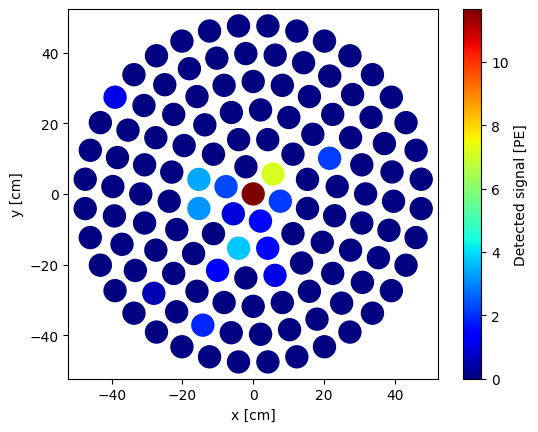

In [5]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))

def plot_signal(signal):
    """Plot the signal detected by the PMTs"""
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.gca().set_aspect('equal')
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')


plot_signal(simulate_signal(np.array([[0, 0]]), photons=30)[0])

Note from Jelle: not sure this idea of a permutation invariant loss will work. Maybe instead have a fifth output containing the ratio of secondary top primary scatter, and train on hitpatterns where the ratio is clearly less than 0.5 so swapping the first and second seems unlikely.

In [6]:
def permutation_invariant_loss(y_true, y_pred):
    """
    Computes a permutation-invariant Mean Squared Error loss.
    y_true and y_pred are expected to have shape (batch_size, 4),
    representing [x1, y1, x2, y2].
    """
    # Slice the tensors into the two respective (x, y) coordinates
    p1_true = y_true[:, 0:2]
    p2_true = y_true[:, 2:4]

    p1_pred = y_pred[:, 0:2]
    p2_pred = y_pred[:, 2:4]

    # Sum of squared errors for Assignment 1: (p1_true -> p1_pred) & (p2_true -> p2_pred)
    d1 = ops.sum(ops.square(p1_true - p1_pred), axis=1) + ops.sum(ops.square(p2_true - p2_pred), axis=1)

    # Sum of squared errors for Assignment 2: (p1_true -> p2_pred) & (p2_true -> p1_pred)
    d2 = ops.sum(ops.square(p1_true - p2_pred), axis=1) + ops.sum(ops.square(p2_true - p1_pred), axis=1)

    # Take the minimum distance per sample in the batch, then average across the batch
    return ops.mean(ops.minimum(d1, d2))

def build_double_scatter_model(input_dim=127):
    inputs = keras.Input(shape=(input_dim,), name="s2_hitpattern")

    # 4 Hidden Layers
    x = layers.Dense(256, activation="relu")(inputs)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)

    # Output layer: 4 linear neurons mapping to x1, y1, x2, y2
    outputs = layers.Dense(4, activation="linear", name="xy_positions")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    # Compile with the custom physics-informed loss
    model.compile(optimizer="adam", loss=permutation_invariant_loss)

    return model

model = build_double_scatter_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ s2_hitpattern (InputLayer)      │ (None, 127)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xy_positions (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,132 (297.39 KB)

 Trainable params: 76,132 (297.39 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train model on random hitpattersn
model.compile(optimizer="adam", loss=permutation_invariant_loss)
X_train = np.random.rand(1000, 127)  # Dummy hit patterns
y_train = np.random.rand(1000, 4)     # Dummy (x1, y1, x2, y2) positions
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3719
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2788
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2677
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2586
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2533
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2535
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2424
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2420
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2239
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2187
